## PRACTICA MOIRE

Text(0.5, 1.0, 'Original')

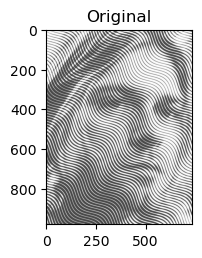

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('img.jpg')
plt.subplot(1,3,1)
plt.imshow(img)
plt.title('Original')

## APLICACION

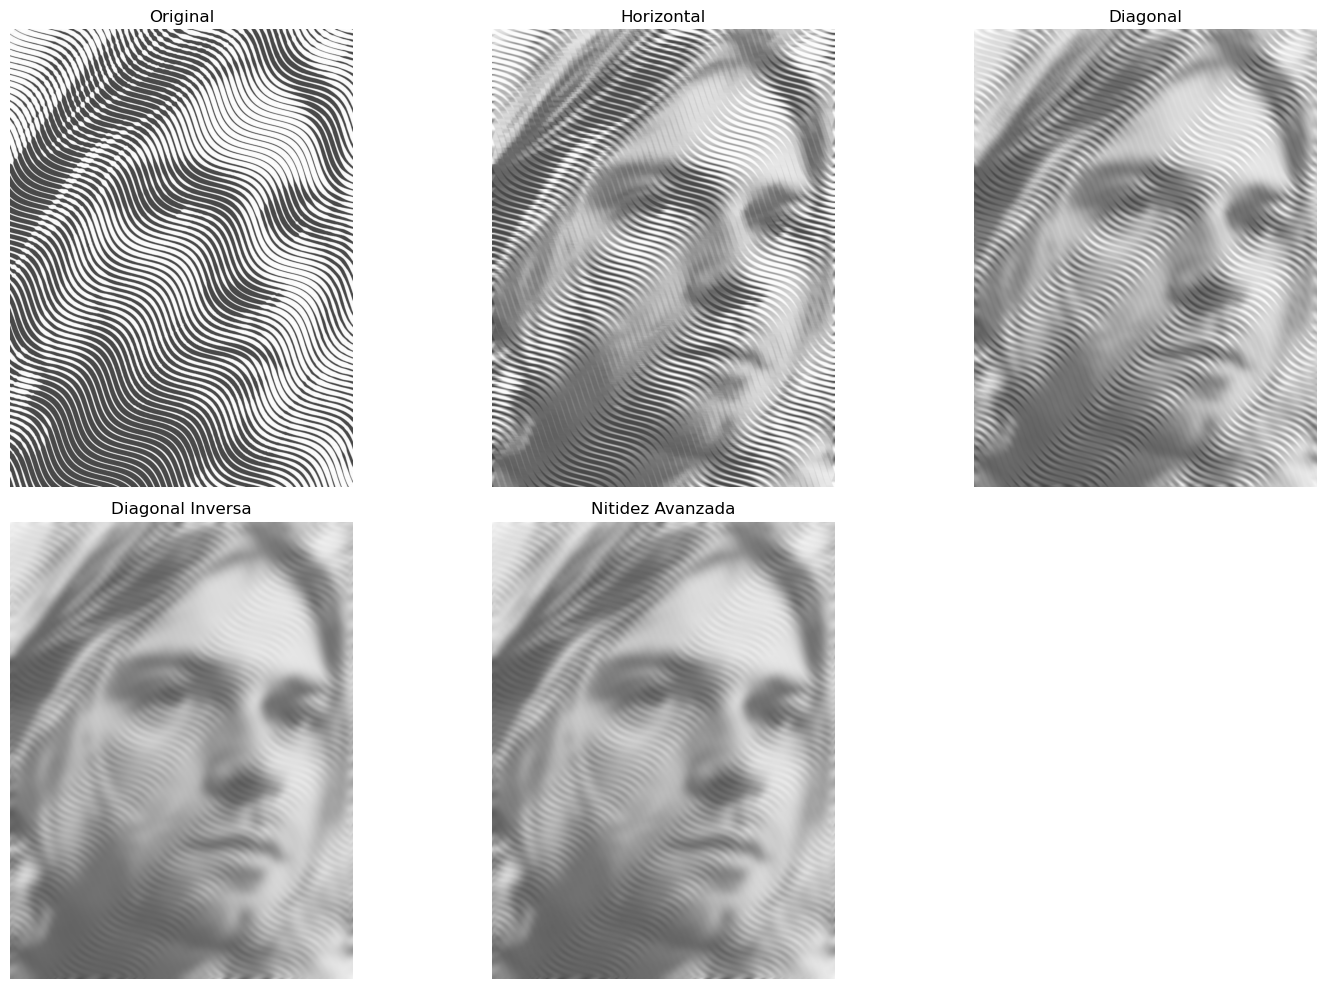

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convolucion_horizontal(imagen, k):
    kernel = np.ones((1, k), np.float32) / k
    return cv2.filter2D(imagen, -1, kernel)

# diagonal
def convolucion_diagonal(imagen, k):
    kernel = np.zeros((k, k), np.float32)
    np.fill_diagonal(kernel, 1)
    kernel = kernel / k
    return cv2.filter2D(imagen, -1, kernel)

# diagonal inversa 
def convolucion_diagonal_inv(imagen, k):
    kernel = np.zeros((k, k), np.float32)
    kernel = np.fliplr(np.eye(k, dtype=np.float32))
    kernel = kernel / k
    return cv2.filter2D(imagen, -1, kernel)

# --- Nitidez  ---
def nitidez_avanzada(imagen):
    blur = cv2.GaussianBlur(imagen, (0,0), 3)
    return cv2.addWeighted(imagen, 1.5, blur, -0.5, 0)


img = cv2.imread('IMG.jpg')
imagen = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

k = 15


img_h = convolucion_horizontal(imagen, k)
img_d = convolucion_diagonal(img_h, k)
img_d_i = convolucion_diagonal_inv(img_d, k)
img_nitida = nitidez_avanzada(img_d_i)


plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(imagen)
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(img_h)
plt.title('Horizontal')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(img_d)
plt.title('Diagonal')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(img_d_i)
plt.title('Diagonal Inversa')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(img_nitida)
plt.title('Nitidez Avanzada')
plt.axis('off')
plt.tight_layout()
plt.show()